In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set consistent plot style for EDA
sns.set_theme(style="whitegrid")

print("--- Loading Datasets ---")
# Adjust paths to match your directory structure
fraud_df = pd.read_csv("Data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("Data/raw/IpAddress_to_Country.csv")

print(f"Fraud Data Shape: {fraud_df.shape}")
print(f"IP Mapping Data Shape: {ip_df.shape}\n")

--- Loading Datasets ---
Fraud Data Shape: (151112, 11)
IP Mapping Data Shape: (138846, 3)



Data Cleaning

In [7]:
print("--- Step 1: Data Cleaning ---")

# 1.1 Remove Duplicates
fraud_df.drop_duplicates(inplace=True)
ip_df.drop_duplicates(inplace=True)
print(f"Shapes after removing duplicates: Fraud={fraud_df.shape}, IP={ip_df.shape}")

# 1.2 Correct Data Types
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

# 1.3 Handle Missing Values
print("\nMissing values in Fraud Data:")
print(fraud_df.isnull().sum())

# Justification: Drop rows missing crucial target labels or user identifiers.
# If features like age or purchase_value have missing records, use an imputer instead.
fraud_df.dropna(subset=["user_id", "class"], inplace=True)

--- Step 1: Data Cleaning ---
Shapes after removing duplicates: Fraud=(151112, 11), IP=(138846, 3)

Missing values in Fraud Data:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


Geolocation Integration (Optimized Range Lookup)

In [9]:
print("Fraud Data Columns:", fraud_df.columns.tolist())
print("IP Data Columns:", ip_df.columns.tolist())

Fraud Data Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']
IP Data Columns: ['lower_bound_ip_address', 'upper_bound_ip_address', 'country']


In [10]:
print("\n--- Step 3: Geolocation Integration ---")

# 3.1 Convert IP addresses to integer format
def ip_to_int(ip):
    try:
        return int(float(ip))
    except (ValueError, TypeError):
        parts = list(map(int, str(ip).split(".")))
        return (parts[0] << 24) + (parts[1] << 16) + (parts[2] << 8) + parts[3]

# Apply using your exact column names
fraud_df["ip_int"] = fraud_df["ip_address"].apply(ip_to_int)
ip_df["lower_bound_int"] = ip_df["lower_bound_ip_address"].apply(ip_to_int)
ip_df["upper_bound_int"] = ip_df["upper_bound_ip_address"].apply(ip_to_int)

# 3.2 Merge using Binary Search
ip_df = ip_df.sort_values(by="lower_bound_int").reset_index(drop=True)

# Find index locations where fraud IPs fit within the sorted lower bound boundaries
pos = np.searchsorted(ip_df["lower_bound_int"].values, fraud_df["ip_int"].values) - 1
pos = np.clip(pos, 0, len(ip_df) - 1)

# Map values based on array alignments
fraud_df["country"] = ip_df["country"].iloc[pos].values
fraud_df["upper_bound"] = ip_df["upper_bound_int"].iloc[pos].values

# Post-verification: If an IP exceeds the mapped upper boundary, label it as "Unknown"
fraud_df.loc[fraud_df["ip_int"] > fraud_df["upper_bound"], "country"] = "Unknown"
fraud_df.drop(columns=["upper_bound"], inplace=True)

print("IP Merge completed successfully.")


--- Step 3: Geolocation Integration ---
IP Merge completed successfully.


Feature Engineering

In [11]:
print("\n--- Step 4: Feature Engineering ---")

# 4.1 Time features
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek

# 4.2 time_since_signup (converted to a clean float representation in minutes)
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds() / 60.0

# 4.3 Transaction frequency and velocity features
# Total purchases made by the exact same user ID
fraud_df["user_tx_count"] = fraud_df.groupby("user_id")["user_id"].transform("count")

# Velocity: Calculate duration tracking fast-succession purchases
fraud_df = fraud_df.sort_values(by=["user_id", "purchase_time"])
fraud_df["time_diff_prev_tx"] = fraud_df.groupby("user_id")["purchase_time"].diff().dt.total_seconds() / 60.0
fraud_df["time_diff_prev_tx"] = fraud_df["time_diff_prev_tx"].fillna(-1)  # -1 marks the initial user baseline


--- Step 4: Feature Engineering ---


Exploratory Data Analysis (EDA)


--- Step 2 & 3.3: Exploratory Data Analysis ---
Class Distribution:
class
0    136961
1     14151
Name: count, dtype: int64
Percentage:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


/var/folders/d9/fl1vk6zx3p950w23l303nhy40000gn/T/ipykernel_2717/2698141777.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_df, x="class", y="purchase_value", ax=axes[0, 1], palette="Set2")
/var/folders/d9/fl1vk6zx3p950w23l303nhy40000gn/T/ipykernel_2717/2698141777.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1, 0], palette="pastel")
/var/folders/d9/fl1vk6zx3p950w23l303nhy40000gn/T/ipykernel_2717/2698141777.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fr

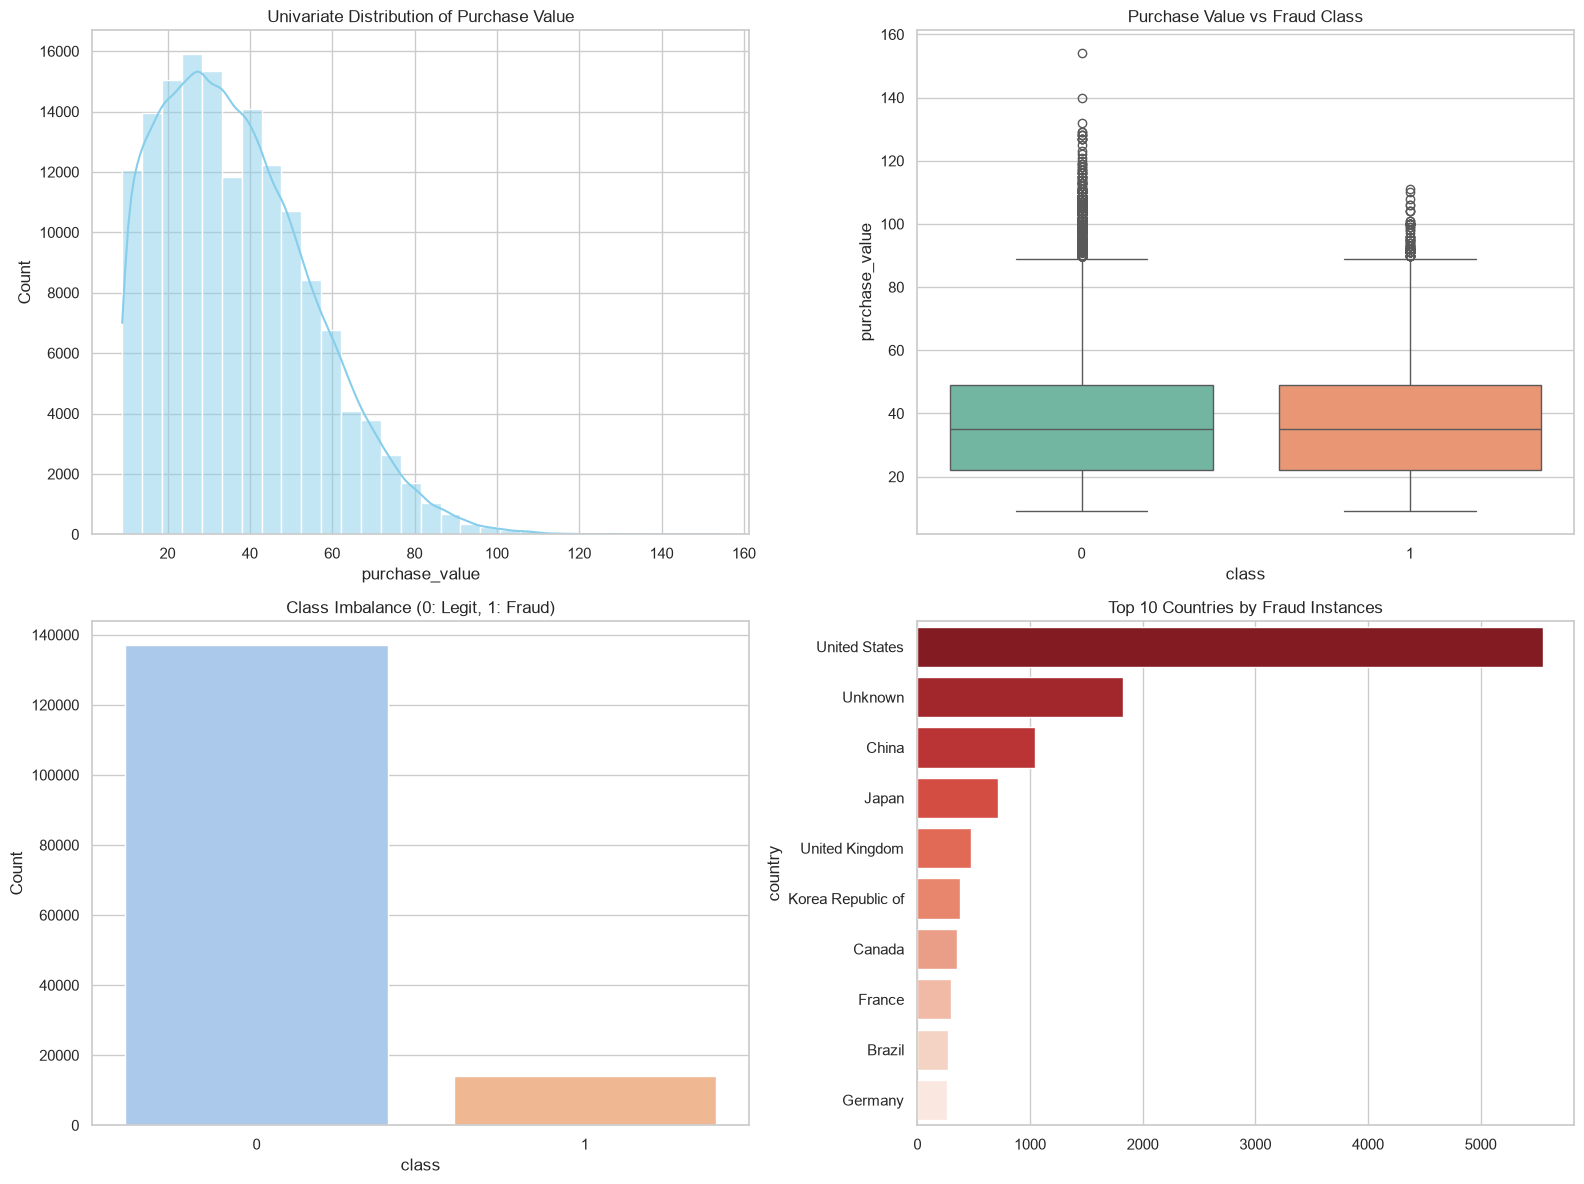

In [12]:
print("\n--- Step 2 & 3.3: Exploratory Data Analysis ---")

# 2.3 Quantify Class Imbalance
class_counts = fraud_df["class"].value_counts()
class_pct = fraud_df["class"].value_counts(normalize=True) * 100
print(f"Class Distribution:\n{class_counts}")
print(f"Percentage:\n{class_pct}")

# Set up matplotlib Canvas layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Univariate Distribution (Purchase Value)
sns.histplot(data=fraud_df, x="purchase_value", kde=True, ax=axes[0, 0], bins=30, color="skyblue")
axes[0, 0].set_title("Univariate Distribution of Purchase Value")

# Plot 2: Bivariate Relationship (Purchase Value vs Fraud Class)
sns.boxplot(data=fraud_df, x="class", y="purchase_value", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Purchase Value vs Fraud Class")

# Plot 3: Class Imbalance Visualization
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1, 0], palette="pastel")
axes[1, 0].set_title("Class Imbalance (0: Legit, 1: Fraud)")
axes[1, 0].set_ylabel("Count")

# Plot 4: Top 10 Fraud Countries
top_fraud_countries = fraud_df[fraud_df["class"] == 1]["country"].value_counts().head(10)
sns.barplot(x=top_fraud_countries.values, y=top_fraud_countries.index, ax=axes[1, 1], palette="Reds_r")
axes[1, 1].set_title("Top 10 Countries by Fraud Instances")

plt.tight_layout()
plt.show()

In [13]:
print("\n--- Step 5: Data Transformation ---")

# Updated 'ip_address' here to match your dataset
features_to_drop = ["user_id", "signup_time", "purchase_time", "device_id", "ip_address", "ip_int"]
X = fraud_df.drop(columns=features_to_drop + ["class"])
y = fraud_df["class"]

# Stratified Split ensuring proportional representations of the minority fraud records
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Categorization
num_cols = ["purchase_value", "age", "hour_of_day", "day_of_week", "time_since_signup", "user_tx_count", "time_diff_prev_tx"]
cat_cols = ["source", "browser", "sex", "country"]

# Dimension Reduction for Categorical Features (Group uncommon countries to prevent sparse matrices)
top_countries = X_train["country"].value_counts().index[:20]
X_train["country"] = X_train["country"].apply(lambda x: x if x in top_countries else "Other")
X_test["country"] = X_test["country"].apply(lambda x: x if x in top_countries else "Other")

# One-Hot Encoding
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = pd.DataFrame(ohe.fit_transform(X_train[cat_cols]), index=X_train.index, columns=ohe.get_feature_names_out(cat_cols))
X_test_encoded = pd.DataFrame(ohe.transform(X_test[cat_cols]), index=X_test.index, columns=ohe.get_feature_names_out(cat_cols))

# Scaling Numerical Features using StandardScaler (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), index=X_train.index, columns=num_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[num_cols]), index=X_test.index, columns=num_cols)

# Concatenate numerical and categorical matrices back together
X_train_final = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

print(f"Final Preprocessed Training Feature Shape: {X_train_final.shape}")


--- Step 5: Data Transformation ---
Final Preprocessed Training Feature Shape: (120889, 38)


In [14]:
print("\n--- Step 6: Handle Class Imbalance ---")

print("Class distribution before SMOTE:")
print(y_train.value_counts(normalize=True))

# Initialize and apply Synthetic Minority Over-sampling Technique
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts(normalize=True))

print("\nPreprocessing Pipeline Executed Successfully!")


--- Step 6: Handle Class Imbalance ---
Class distribution before SMOTE:
class
0    0.906352
1    0.093648
Name: proportion, dtype: float64

Class distribution after SMOTE:
class
0    0.5
1    0.5
Name: proportion, dtype: float64

Preprocessing Pipeline Executed Successfully!


In [15]:
import os

print("\n--- Updated Step 7: Saving Cleaned Data for Task 2 ---")

processed_dir = os.path.join("Data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Save the entire clean, transformed feature set (X) and target (y) 
# without SMOTE so Task 2 can handle the splitting and CV properly.
X_train_final.to_csv(os.path.join(processed_dir, "X_train_clean.csv"), index=False)
y_train.to_csv(os.path.join(processed_dir, "y_train_clean.csv"), index=False)
X_test_final.to_csv(os.path.join(processed_dir, "X_test_clean.csv"), index=False)
y_test.to_csv(os.path.join(processed_dir, "y_test_clean.csv"), index=False)

print("Data saved successfully for Task 2 modeling!")


--- Updated Step 7: Saving Cleaned Data for Task 2 ---
Data saved successfully for Task 2 modeling!
